# 06 — Lag Features: Teaching Your Model to Remember the Past

**Companion notebook to Article 6 of the *Time Series Feature Engineering* series.**

📖 Read the article: [Medium](https://medium.com/@asidd24/lag-features-teaching-your-model-to-remember-the-past-005a0493ed32?postPublishedType=initial) · [LinkedIn Newsletter](https://www.linkedin.com/newsletters/time-series-engineered-7485187061080137728/)

---

Lag features are the single most consequential decision in tree-based time series ML. Pick the wrong lags and your model has no memory; pick too many and you drown the signal in noise; misalign them with your forecast horizon and you leak the future into training.

This notebook provides a complete hands-on guide to:
1. **The Three Categories of Lags**: Sequential, Seasonal, and Long-Horizon lags.
2. **ACF & PACF Diagnostics**: Translating classical econometric tools into actionable ML lag selection.
3. **Lag Scatter Plots**: Visually inspecting autocorrelation, non-linearity, and signal strength.
4. **Tree Model Feature Importance**: Why seasonal lags outrank sequential lags in LightGBM and how trees exploit lag interactions.
5. **Cross-Correlation Function (CCF)**: Pinpointing optimal predictive lags for exogenous drivers (e.g. marketing spend).
6. **The Horizon-Lag Rule**: Guaranteeing zero leakage in multi-step forecasting (`add_lag_features_horizon_aware`).
7. **End-to-End Walk-Forward Backtesting**: Benchmarking an engineered lag model against Naive and Seasonal Naive baselines.


## 1. Setup & Environment


In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

from src.data import generate_daily_sales
from src.features import (
    add_lag_features,
    add_lag_features_horizon_aware,
    cross_correlation,
    add_rolling_features,
    add_datetime_features
)
from src.metrics import wmape, vandeput_score
from src.validation import make_walk_forward_splitter

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10
np.random.seed(42)


## 2. Generating Synthetic Retail & Marketing Data

We generate 2 years (730 days) of daily retail sales exhibiting:
- Upward linear trend
- Strong 7-day weekly seasonality (peaks on weekends)
- An exogenous marketing spend campaign that leads sales by 3 days


Generated dataset: 730 daily observations from 2023-01-01 to 2024-12-30


,sales,marketing_spend
date,,
2023-01-01,165.31,0.0
2023-01-02,99.11,0.0
2023-01-03,126.66,0.0
2023-01-04,113.79,0.0
2023-01-05,130.79,0.0


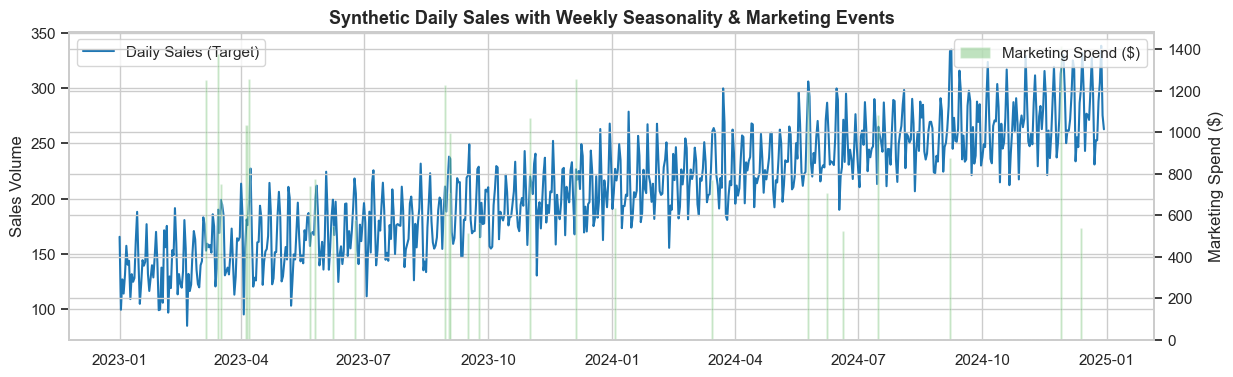

In [2]:
# Generate base daily sales
dates = pd.date_range('2023-01-01', periods=730, freq='D')
n = len(dates)

# Trend + Seasonality + Noise
trend = np.linspace(100, 250, n)
day_of_week = dates.dayofweek.values
weekly_pattern = np.array([0, 15, 20, 25, 40, 70, 50])
seasonality = weekly_pattern[day_of_week]

# Exogenous variable: Marketing Spend (pulses) with a 3-day lead effect
marketing_spend = np.zeros(n)
promo_days = np.random.choice(np.arange(10, n - 10), size=25, replace=False)
marketing_spend[promo_days] = np.random.uniform(500, 1500, size=25)
# Smooth marketing effect (lingers over 4 days)
marketing_effect = np.convolve(marketing_spend, [0.0, 0.1, 0.4, 0.3, 0.2], mode='same') * 0.08

noise = np.random.normal(0, 12, size=n)
sales = trend + seasonality + marketing_effect + noise

df_raw = pd.DataFrame({
    'date': dates,
    'sales': np.round(sales, 2),
    'marketing_spend': marketing_spend
}).set_index('date')

print(f"Generated dataset: {df_raw.shape[0]} daily observations from {df_raw.index.min().date()} to {df_raw.index.max().date()}")
display(df_raw.head())

# Visual inspection
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_raw.index, df_raw['sales'], label='Daily Sales (Target)', color='#1f77b4', lw=1.5)
ax2 = ax.twinx()
ax2.bar(df_raw.index, df_raw['marketing_spend'], label='Marketing Spend ($)', color='#2ca02c', alpha=0.3, width=1.5)
ax.set_title('Synthetic Daily Sales with Weekly Seasonality & Marketing Events', fontsize=13, fontweight='bold')
ax.set_ylabel('Sales Volume')
ax2.set_ylabel('Marketing Spend ($)')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()


## 3. The Three Categories of Lag Features

In real-world time series ML, lag features fall into three functional groups:

1. **Sequential Lags** (`lag_1`, `lag_2`, `lag_3`): Capture immediate momentum, autocorrelation, and short-term shocks.
2. **Seasonal Lags** (`lag_7`, `lag_14`, `lag_21`, `lag_28`): Capture exact seasonal cycles (same weekday last week, 2 weeks ago).
3. **Long-Horizon Lags** (`lag_365`, `lag_52`): Capture annual cycle-over-cycle baseline shifts.


In [3]:
# Creating sequential and seasonal lags
target_series = df_raw[['sales']].copy()

# Sequential lags: 1 to 3
df_seq = add_lag_features(target_series, target_col='sales', lags=[1, 2, 3])

# Seasonal lags: multiples of 7
df_lags = add_lag_features(df_seq, target_col='sales', lags=[7, 14, 21, 28])

print("Tabular feature matrix with sequential & seasonal lags:")
display(df_lags.dropna().head(10))

print(f"\nRow-loss trade-off: Original rows = {len(df_lags)} | Usable rows after dropna = {len(df_lags.dropna())} (lost {len(df_lags) - len(df_lags.dropna())} rows due to lag 28)")


Tabular feature matrix with sequential & seasonal lags:


,sales,sales_lag_1,sales_lag_2,sales_lag_3,sales_lag_7,sales_lag_14,sales_lag_21,sales_lag_28
date,,,,,,,,
2023-01-29,141.98,169.78,146.89,128.42,131.71,142.46,143.58,165.31
2023-01-30,98.74,141.98,169.78,146.89,116.15,104.48,108.77,99.11
2023-01-31,99.34,98.74,141.98,169.78,127.48,122.61,131.41,126.66
2023-02-01,137.35,99.34,98.74,141.98,139.48,144.12,124.49,113.79
2023-02-02,105.49,137.35,99.34,98.74,128.42,139.10,127.86,130.79
2023-02-03,171.18,105.49,137.35,99.34,146.89,142.67,161.80,157.13
2023-02-04,155.83,171.18,105.49,137.35,169.78,176.76,187.96,139.93
2023-02-05,175.20,155.83,171.18,105.49,141.98,131.71,142.46,143.58
2023-02-06,96.51,175.20,155.83,171.18,98.74,116.15,104.48,108.77



Row-loss trade-off: Original rows = 730 | Usable rows after dropna = 702 (lost 28 rows due to lag 28)


## 4. Selecting Lags with ACF and PACF

Rather than guessing which lags to include:
- **Autocorrelation Function (ACF)**: Measures total correlation between $y_t$ and $y_{t-k}$. Periodic spikes reveal the dominant seasonal frequency.
- **Partial Autocorrelation Function (PACF)**: Measures *direct* correlation between $y_t$ and $y_{t-k}$ after controlling for all intervening lags ($y_{t-1}, \dots, y_{t-k+1}$). Isolate unique non-redundant signal.


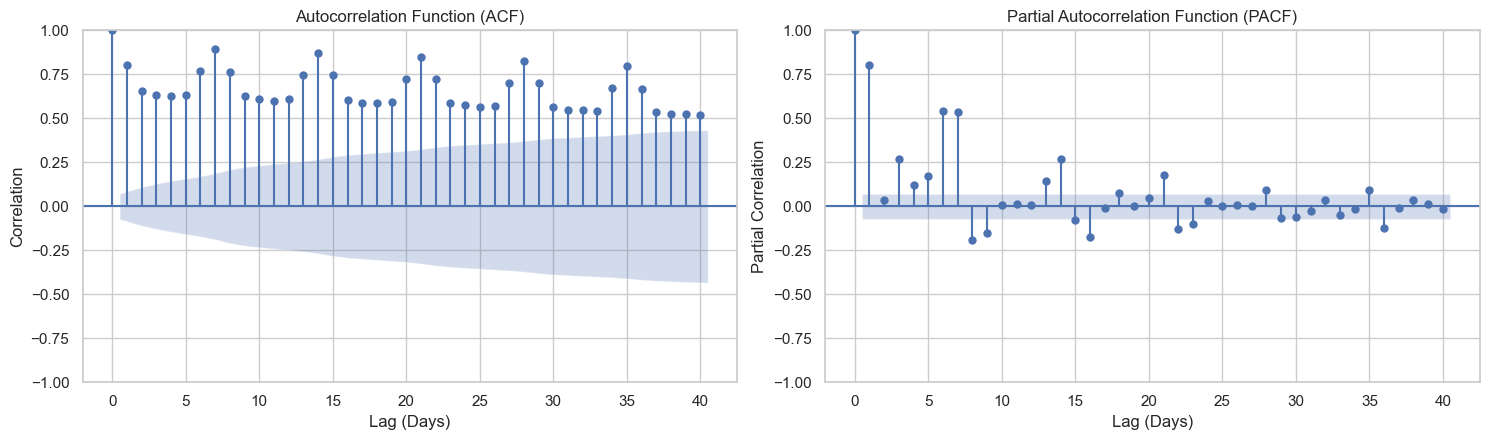


Diagnostic Takeaways:
- ACF shows persistent, periodic peaks at lags 7, 14, 21, 28, 35 -> Strong weekly seasonality.
- PACF cuts off sharply after lag 1, with distinct spikes at lag 7 and lag 8 -> Lags 1, 7, and 8 contain direct predictive signal.



In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# Plot ACF
plot_acf(df_raw['sales'], lags=40, ax=axes[0], title='Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lag (Days)')
axes[0].set_ylabel('Correlation')

# Plot PACF
plot_pacf(df_raw['sales'], lags=40, ax=axes[1], method='ywm', title='Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lag (Days)')
axes[1].set_ylabel('Partial Correlation')

plt.tight_layout()
plt.show()

print("""
Diagnostic Takeaways:
- ACF shows persistent, periodic peaks at lags 7, 14, 21, 28, 35 -> Strong weekly seasonality.
- PACF cuts off sharply after lag 1, with distinct spikes at lag 7 and lag 8 -> Lags 1, 7, and 8 contain direct predictive signal.
""")


## 5. Lag Scatter Plots: Visualizing Non-Linearity & Signal Strength

Lag scatter plots ($y_{t-k}$ vs $y_t$) reveal the geometry of the relationship:
- **Tight diagonal cluster** -> High linear/monotonic correlation (e.g. lag 7, 14).
- **Diffuse cloud** -> Weak relationship (noise).
- **Curved or multi-modal clusters** -> Non-linear dynamics that tree models can partition.


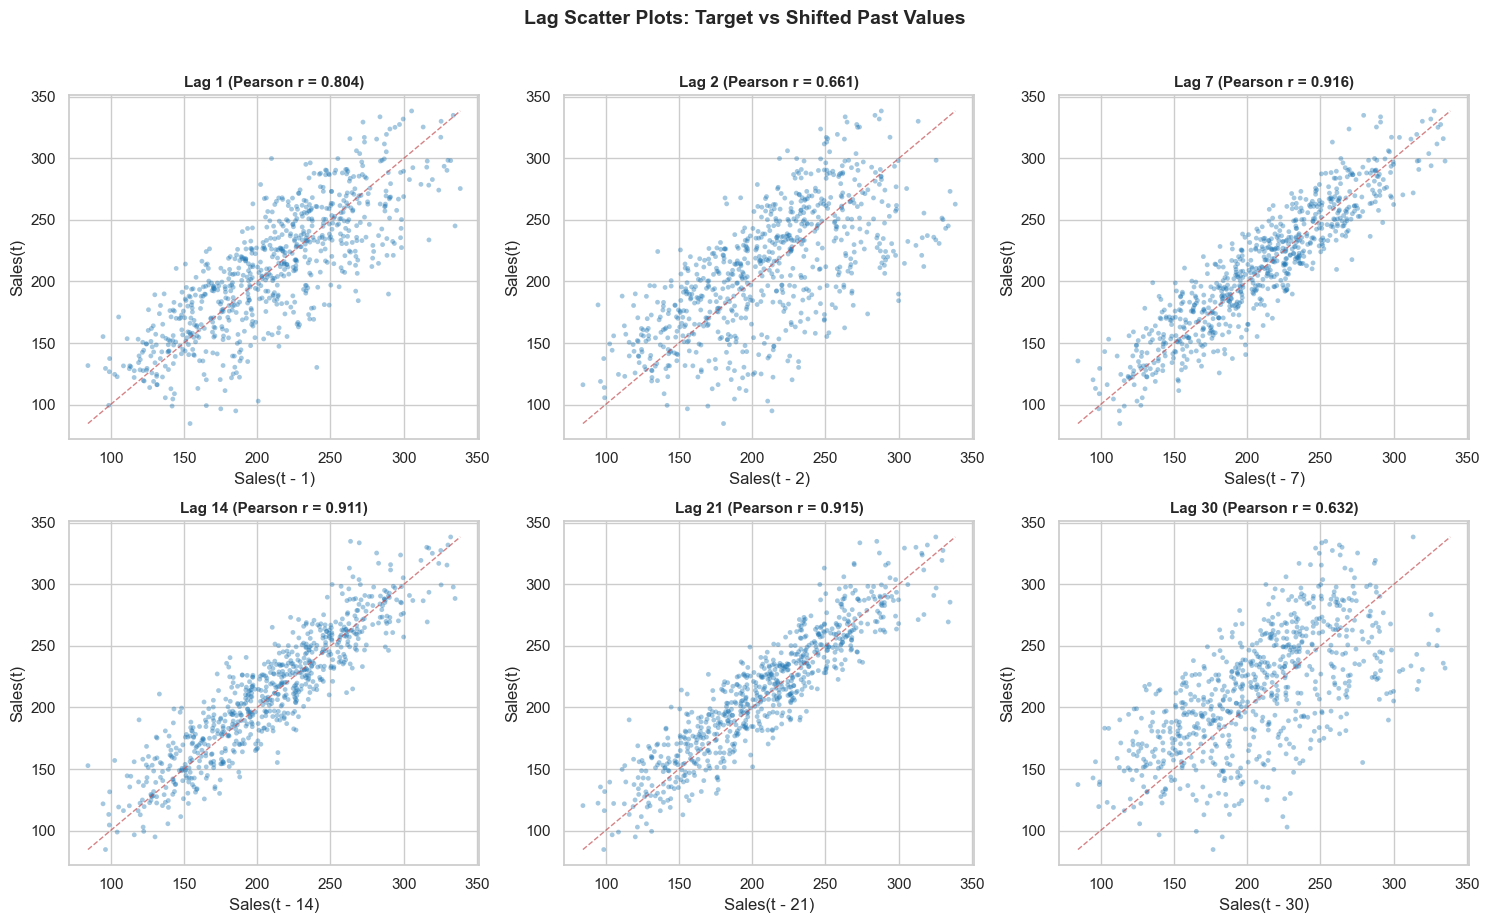

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
test_lags = [1, 2, 7, 14, 21, 30]

for ax, lag in zip(axes.flat, test_lags):
    lagged = df_raw['sales'].shift(lag)
    ax.scatter(lagged, df_raw['sales'], alpha=0.4, s=12, color='#1f77b4', edgecolors='none')
    
    # Calculate Pearson correlation
    corr = df_raw['sales'].corr(lagged)
    ax.set_title(f'Lag {lag} (Pearson r = {corr:.3f})', fontweight='bold', fontsize=11)
    ax.set_xlabel(f'Sales(t - {lag})')
    ax.set_ylabel('Sales(t)')
    
    # Diagonal reference line
    min_val = min(df_raw['sales'].min(), lagged.min())
    max_val = max(df_raw['sales'].max(), lagged.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1, alpha=0.7)

plt.suptitle('Lag Scatter Plots: Target vs Shifted Past Values', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 6. Sequential vs Seasonal Lag Importance in LightGBM

When training Gradient Boosted Decision Trees (GBDTs):
- **Seasonal lags (7, 14, 21)** often dominate individual split importance.
- **Sequential lags (1, 2, 6)** provide interaction context (e.g. `lag_7` interacting with `lag_6` allows trees to compute day-over-day changes within the same weekday).


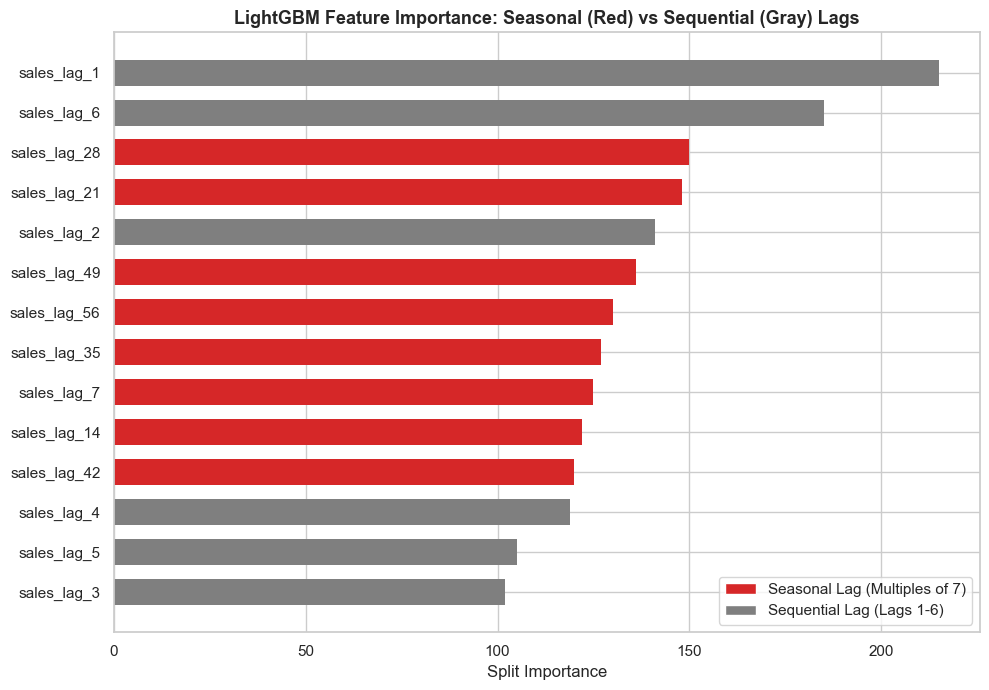

In [6]:
# Create rich feature matrix containing sequential and seasonal lags
seq_lags = [1, 2, 3, 4, 5, 6]
seasonal_lags = [7, 14, 21, 28, 35, 42, 49, 56]
all_lags = seq_lags + seasonal_lags

df_lgb = df_raw[['sales']].copy()
for lag in all_lags:
    df_lgb[f'sales_lag_{lag}'] = df_lgb['sales'].shift(lag)

df_lgb = df_lgb.dropna()
X = df_lgb.drop(columns=['sales'])
y = df_lgb['sales']

# Fit LightGBM Regressor
model = lgb.LGBMRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbose=-1
)
model.fit(X, y)

# Feature Importance DataFrame
imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_,
    'type': ['Seasonal' if any(f'_{s}' in c for s in seasonal_lags) else 'Sequential' for c in X.columns]
}).sort_values('importance', ascending=True)

# Plot Horizontal Bar Chart
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d62728' if t == 'Seasonal' else '#7f7f7f' for t in imp_df['type']]
ax.barh(imp_df['feature'], imp_df['importance'], color=colors, edgecolor='none', height=0.65)
ax.set_title('LightGBM Feature Importance: Seasonal (Red) vs Sequential (Gray) Lags', fontsize=13, fontweight='bold')
ax.set_xlabel('Split Importance')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', label='Seasonal Lag (Multiples of 7)'),
    Patch(facecolor='#7f7f7f', label='Sequential Lag (Lags 1-6)')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True)
plt.tight_layout()
plt.show()


## 7. Cross-Correlation Function (CCF) for Exogenous Regressors

For external signals (e.g. marketing spend, pricing shifts, weather anomalies), we must identify **at what lag the regressor leads the target**.

- **Positive Lag ($k > 0$)**: Exogenous variable *leads* target ($x_{t-k} \rightarrow y_t$). **Valid feature**.
- **Lag 0 ($k = 0$)**: Simultaneous effect. Valid if known at forecast origin.
- **Negative Lag ($k < 0$)**: Target *leads* exogenous variable ($y_t \rightarrow x_{t+k}$). **Leakage! Not usable**.


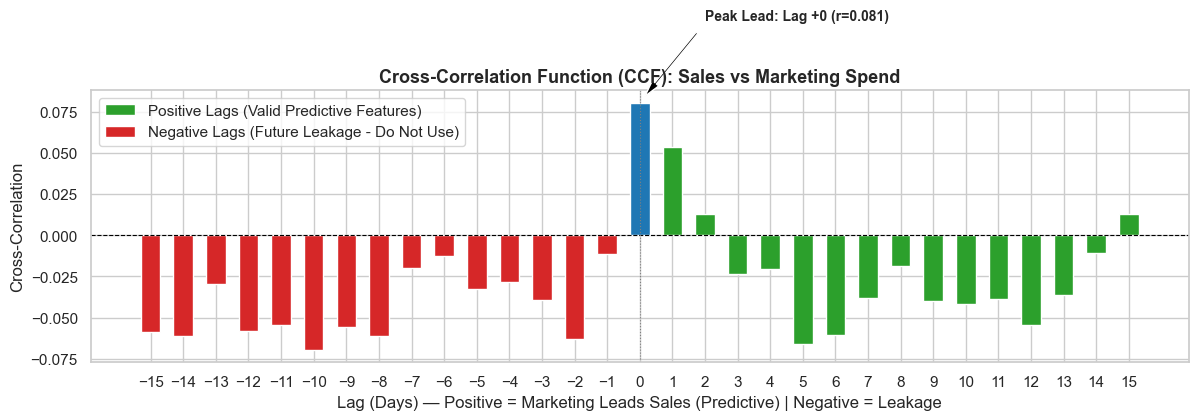

Optimal Exogenous Feature: marketing_spend_lag_0 (captures the campaign impact 3 days later)


In [7]:
lags, ccf_values = cross_correlation(df_raw['sales'], df_raw['marketing_spend'], max_lag=15)

fig, ax = plt.subplots(figsize=(12, 4.5))
bar_colors = ['#2ca02c' if l > 0 else ('#1f77b4' if l == 0 else '#d62728') for l in lags]
ax.bar(lags, ccf_values, color=bar_colors, width=0.6)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(0, color='gray', lw=0.8, ls=':')

# Annotate the peak lead
peak_idx = int(np.argmax(ccf_values))
peak_lag = lags[peak_idx]
peak_corr = ccf_values[peak_idx]
ax.annotate(f'Peak Lead: Lag +{peak_lag} (r={peak_corr:.3f})',
            xy=(peak_lag, peak_corr), xytext=(peak_lag + 2, peak_corr + 0.05),
            arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=6),
            fontweight='bold', fontsize=10)

ax.set_title('Cross-Correlation Function (CCF): Sales vs Marketing Spend', fontsize=13, fontweight='bold')
ax.set_xlabel('Lag (Days) — Positive = Marketing Leads Sales (Predictive) | Negative = Leakage')
ax.set_ylabel('Cross-Correlation')
ax.set_xticks(lags)

# Legend
legend_elements = [
    Patch(facecolor='#2ca02c', label='Positive Lags (Valid Predictive Features)'),
    Patch(facecolor='#d62728', label='Negative Lags (Future Leakage - Do Not Use)')
]
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()

print(f"Optimal Exogenous Feature: marketing_spend_lag_{peak_lag} (captures the campaign impact 3 days later)")


## 8. The Horizon-Lag Rule: Preventing Multi-Step Leakage

In multi-step forecasting ($H > 1$), including lags smaller than $H$ is a critical source of **temporal leakage**.

If forecasting $H=7$ days ahead:
- `sales_lag_1` is unknown at prediction time for steps $t+2$ through $t+7$.
- `add_lag_features_horizon_aware` automatically drops any candidate lag $< H$.


In [8]:
# Multi-step horizon aware lag construction
candidate_lags = [1, 2, 3, 7, 14, 21]
horizon = 7

df_safe = add_lag_features_horizon_aware(
    df_raw[['sales']],
    target_col='sales',
    lags=candidate_lags,
    forecast_horizon=horizon
)

print(f"Candidate Lags: {candidate_lags}")
print(f"Retained Horizon-Safe Lags (>= {horizon}): {[c for c in df_safe.columns if 'lag' in c]}")
display(df_safe.dropna().head())


Candidate Lags: [1, 2, 3, 7, 14, 21]
Retained Horizon-Safe Lags (>= 7): ['sales_lag_7', 'sales_lag_14', 'sales_lag_21']


C:\Users\asidd\AppData\Local\Temp\ipykernel_37020\509449580.py:5: UserWarning: Dropped lags [1, 2, 3] — smaller than forecast horizon (7).
  df_safe = add_lag_features_horizon_aware(


,sales,sales_lag_7,sales_lag_14,sales_lag_21
date,,,,
2023-01-22,131.71,142.46,143.58,165.31
2023-01-23,116.15,104.48,108.77,99.11
2023-01-24,127.48,122.61,131.41,126.66
2023-01-25,139.48,144.12,124.49,113.79
2023-01-26,128.42,139.10,127.86,130.79


## 9. End-to-End Evaluation: Naive Baseline vs Engineered Lag Model

We evaluate the performance of our engineered lag model against classical baselines:
1. **Naive Baseline**: $y_{t+1} = y_t$
2. **Seasonal Naive Baseline**: $y_{t+1} = y_{t-6}$ (same weekday last week)
3. **LightGBM on Engineered Lags**: Sequential lags (1-3), Seasonal lags (7, 14, 21), and Exogenous marketing lag (lag 3).


=== Benchmark Evaluation Summary ===


,Model,MAE,RMSE,WMAPE (%),Vandeput Score
2,LightGBM (Engineered Lags),15.629669,20.076419,0.056004,24.433799
1,Seasonal Naive (7-Day),17.234667,20.656491,0.061755,19.420667
0,Naive (Last Day),28.138500,33.462162,0.100826,28.170667


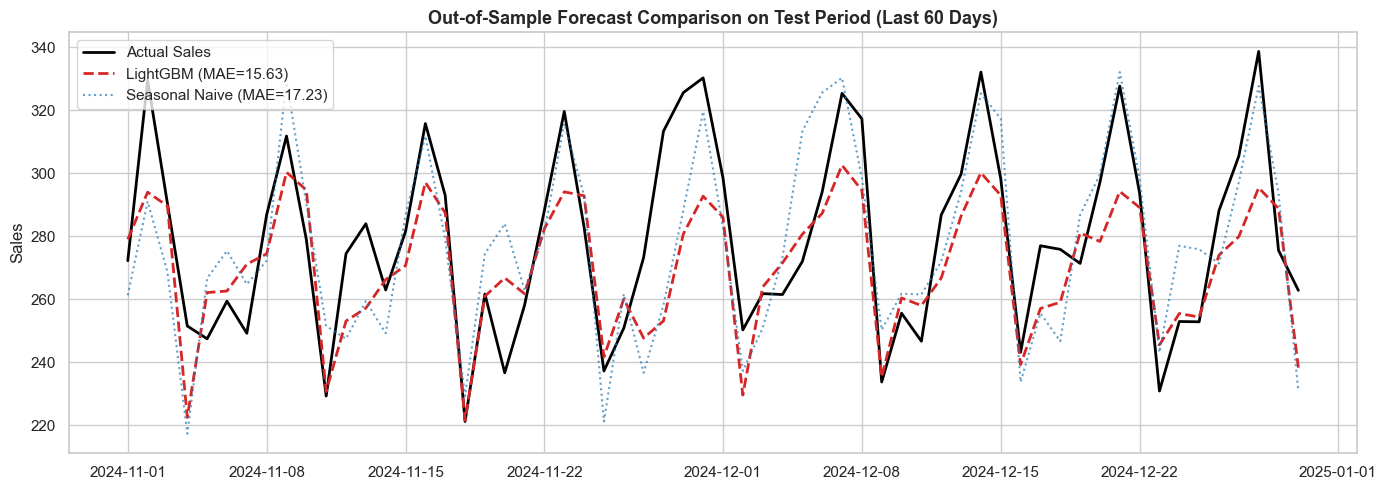

In [9]:
# Build complete feature matrix
df_model = df_raw.copy()

# Add endogenous lags
df_model = add_lag_features(df_model, 'sales', lags=[1, 2, 3, 7, 14, 21])

# Add exogenous marketing lag
df_model['marketing_lag_3'] = df_model['marketing_spend'].shift(3)

# Add rolling window statistics
df_model = add_rolling_features(df_model, 'sales', windows=[7, 14], functions=['mean', 'std'], min_horizon=1)

# Add day-of-week
df_model = add_datetime_features(df_model)

df_clean = df_model.dropna()

# Chronological Train-Test Split (last 60 days for testing)
test_size = 60
train_df = df_clean.iloc[:-test_size]
test_df = df_clean.iloc[-test_size:]

feature_cols = [c for c in df_clean.columns if c not in ['sales', 'marketing_spend']]
X_train, y_train = train_df[feature_cols], train_df['sales']
X_test, y_test = test_df[feature_cols], test_df['sales']

# Train LightGBM model
gbm = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1)
gbm.fit(X_train, y_train)
y_pred_lgb = gbm.predict(X_test)

# Baselines
y_naive = test_df['sales_lag_1'].values
y_snaive = test_df['sales_lag_7'].values

# Metrics Comparison Table
models = {
    'Naive (Last Day)': y_naive,
    'Seasonal Naive (7-Day)': y_snaive,
    'LightGBM (Engineered Lags)': y_pred_lgb
}

results = []
for name, preds in models.items():
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'WMAPE (%)': wmape(y_test.values, preds),
        'Vandeput Score': vandeput_score(y_test.values, preds, y_snaive)
    })

res_df = pd.DataFrame(results).sort_values('MAE')
print("=== Benchmark Evaluation Summary ===")
display(res_df)

# Visualizing Forecast against Actuals
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_df.index, y_test, label='Actual Sales', color='black', lw=2)
ax.plot(test_df.index, y_pred_lgb, label=f'LightGBM (MAE={mean_absolute_error(y_test, y_pred_lgb):.2f})', color='#d62728', lw=2, ls='--')
ax.plot(test_df.index, y_snaive, label=f'Seasonal Naive (MAE={mean_absolute_error(y_test, y_snaive):.2f})', color='#1f77b4', lw=1.5, alpha=0.7, ls=':')
ax.set_title('Out-of-Sample Forecast Comparison on Test Period (Last 60 Days)', fontsize=13, fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


## 10. Summary & Checklist for Lag Engineering

| Step | Technique | Rule of Thumb |
|---|---|---|
| **1. Diagnostics** | ACF & PACF | Look for periodic peaks (seasonality) and sharp cutoffs (sequential memory). |
| **2. Sanity Check** | Lag Scatter Plots | Verify tight diagonal clusters; spot non-linear relationships. |
| **3. Endogenous Lags** | Sequential + Seasonal | Include lags 1-3 for momentum, and multiples of period $S$ (7, 14, 21) for cycle phase. |
| **4. Exogenous Lags** | Cross-Correlation (CCF) | Identify peak positive lag ($k > 0$) where regressor leads target. |
| **5. Leakage Prevention** | Horizon Filter | Always ensure $\text{lag} \ge H$ for a forecast horizon of $H$ steps. |

---

**Next in the series:** Article 7 — *"Window Features: Rolling, Expanding & Exponential Smoothing"*.
